# 2 다중 슬롯머신 문제 (Multi-armed Bandits)

이 장의 실험 전반에서 공통으로 사용하는 `Bandit`과 `GradientBandit` 클래스를 정의한다.

In [ ]:
import numpy as np

class Bandit:
    def __init__(self, k: int = 10, q1: float = 0, mu: float = 0, stationary: bool = True) -> None:
        self.k = k
        self.q_true = np.random.normal(mu, 1, k)
        self.q_estimates = np.full(k, q1, dtype=float)
        self.action_counts = np.zeros(k)
        self.time = 0
        self.stationary = stationary

    def step(self, action: int | np.integer) -> float:
        reward = np.random.normal(self.q_true[action], 1)
        if not self.stationary:
            self.q_true += np.random.normal(0, 0.01, self.k)  # 무작위 보행
        return reward

    def select_action(self, epsilon: float) -> int | np.integer:
        if np.random.rand() < epsilon:
            return np.random.choice(self.k)  # 탐험
        else:
            return np.argmax(self.q_estimates)  # 활용

    def update_estimates(self, action: int | np.integer, reward: float, alpha: float | None = None) -> None:
        self.action_counts[action] += 1
        if alpha is None:
            # 표본 평균 방식
            self.q_estimates[action] += (reward - self.q_estimates[action]) / self.action_counts[action]
        else:
            # 일정 단계 크기 방식
            self.q_estimates[action] += alpha * (reward - self.q_estimates[action])


class GradientBandit:
    def __init__(self, k: int = 10, alpha: float = 0.1, mu: float = 0, use_baseline: bool = True) -> None:
        self.k = k
        self.alpha = alpha
        self.use_baseline = use_baseline
        self.q_true = np.random.normal(mu, 1, k)
        self.preferences = np.zeros(k)
        self.action_counts = np.zeros(k)
        self.average_reward = 0
        self.time = 0

    def softmax(self) -> np.ndarray:
        exp_preferences = np.exp(self.preferences)
        return exp_preferences / np.sum(exp_preferences)

    def select_action(self) -> int | np.integer:
        probabilities = self.softmax()
        return np.random.choice(self.k, p=probabilities)

    def update_preferences(self, action: int | np.integer, reward: float) -> None:
        self.action_counts[action] += 1
        self.time += 1
        probabilities = self.softmax()

        if self.use_baseline:
            self.average_reward += (reward - self.average_reward) / self.time

        baseline = self.average_reward if self.use_baseline else 0
        self.preferences += self.alpha * (reward - baseline) * (np.eye(self.k)[action] - probabilities)


## 2.1 $k$-팔 밴딧 문제

2장은 강화학습 전체 문제 가운데 **상태가 단 하나뿐인 가장 단순한 형태**를 다룬다. 학습자는 매 시점 $k$개의 행동 가운데 하나를 고르고, 선택한 행동에 대응하는 확률 분포에서 수치적 보상을 받는다. 이 구조를 **$k$-팔 밴딧 문제($k$-armed bandit problem)**라 부르며, 슬롯머신(one-armed bandit)에서 이름을 따왔다. 학습자의 목표는 일정 시간 동안 총 보상의 기댓값을 최대화하는 것이다.

각 행동 $a$에는 선택 시 기대할 수 있는 보상이 존재하며, 이를 **참 가치** $q_*(a)$라 한다. 학습자는 이 값을 직접 알 수 없으므로, 과거 경험을 토대로 추정값 $Q_t(a)$를 유지하며 의사결정을 내린다.

추정값이 가장 높은 행동을 **탐욕적 행동(greedy action)**이라 하며, 이를 선택하는 것을 **활용(exploitation)**이라 한다. 반면 추정값이 낮더라도 다른 행동을 의도적으로 시도해 정보를 모으는 것을 **탐험(exploration)**이라 한다.

한 시점에 활용과 탐험을 동시에 할 수는 없다. 둘 사이의 **균형**을 어떻게 잡느냐가 밴딧 알고리즘의 성능을 좌우한다.

### Figure 2.1: 10개의 팔 밴딧 보상 분포

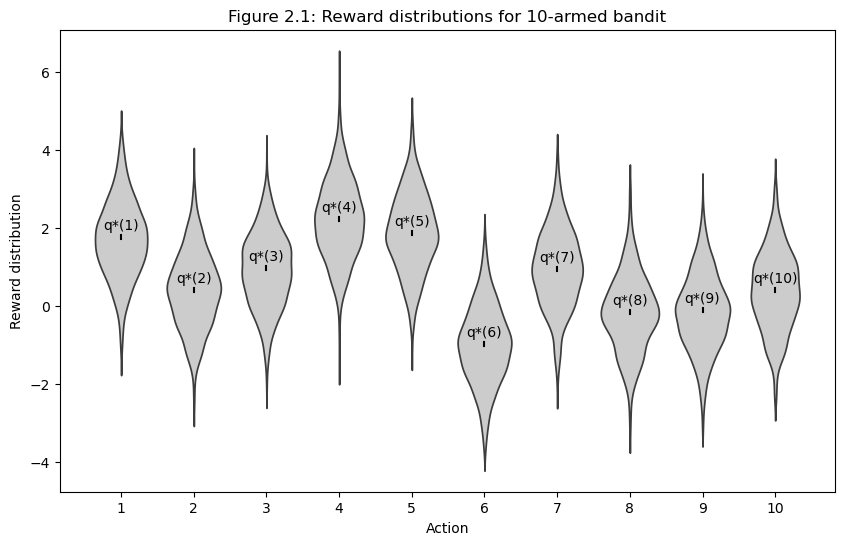

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 재현성을 위한 난수 시드 고정
np.random.seed(0)

# 팔의 수
k = 10

# Bandit 인스턴스 생성
bandit = Bandit(k)

# 각 행동마다 1000개의 보상을 샘플링
rewards = [np.random.normal(bandit.q_true[i], 1, 1000) for i in range(k)]

# 시각화
plt.figure(figsize=(10, 6))

# 보상 분포에 대한 바이올린 플롯 생성
sns.violinplot(data=rewards, inner=None, color=".8")

# 각 행동의 참 가치 q*(a)를 그래프에 표시
for i in range(k):
    plt.plot([i, i], [bandit.q_true[i] - 0.05, bandit.q_true[i] + 0.05], color="black")
    plt.text(i, bandit.q_true[i] + 0.2, f"q*({i+1})", ha="center")

# 축 라벨과 제목
plt.xlabel("Action")
plt.ylabel("Reward distribution")
plt.title("Figure 2.1: Reward distributions for 10-armed bandit")
plt.xticks(range(k), range(1, k+1))

plt.show()


## 2.2 행동 가치 방법

학습자는 행동의 참 가치 $q_*(a)$를 알지 못하므로 이를 추정해야 한다. 가장 단순한 방법은 행동 $a$를 선택할 때마다 받은 보상의 평균을 추정값으로 삼는 **표본 평균(sample average)**이다.

$$Q_t(a) \doteq \frac{\sum_{i=1}^{t-1} R_i \cdot \mathbb{1}_{A_i = a}}{\sum_{i=1}^{t-1} \mathbb{1}_{A_i = a}}$$

행동 $a$를 충분히 많이 고르면 $Q_t(a)$는 큰 수의 법칙에 따라서 $q_*(a)$로 수렴한다.

다음 문제는 이 추정값을 바탕으로 어떻게 행동을 선택하느냐이다. 대표적인 규칙으로 두 가지를 살펴본다. **탐욕적 선택**은 매 시점 추정값이 가장 큰 행동을 선택한다.

$$A_t = \arg\max_a Q_t(a)$$

그러나 탐욕적 선택은 활용에만 치중하므로 새로운 정보를 얻지 못한다. 이를 보완하는 것이 **$\varepsilon$-greedy 방법**이다. 대부분은 탐욕적으로 행동하되, 확률 $\varepsilon$로는 무작위로 행동을 고른다. 충분한 시간이 지나면 모든 행동을 탐험하게 되므로, 이론적으로 추정값이 참 가치로 수렴한다.

### Exercise 2.1: ε-greedy 행동 선택

ε-greedy 행동 선택에서는 확률 $1-\varepsilon$으로 탐욕적 행동을 선택하고, 확률 $\varepsilon$으로 모든 행동 가운데 하나를 무작위로 선택한다. 따라서 탐욕적 행동을 선택할 전체 확률은 두 경로의 합인 $1 - \varepsilon + \dfrac{\varepsilon}{\text{행동 수}}$이고, 비탐욕적 행동 하나하나를 선택할 확률은 $\dfrac{\varepsilon}{\text{행동 수}}$이다.

행동이 두 개($\text{행동 수} = 2$)이고 $\varepsilon = 0.5$인 경우, 탐욕적 행동을 선택할 확률은 다음과 같다.

$$1 - \varepsilon + \frac{\varepsilon}{\text{행동 수}}$$

값을 대입하면

$$1 - 0.5 + \frac{0.5}{2} = 1 - 0.5 + 0.25 = 0.75$$

따라서 행동이 두 개이고 $\varepsilon = 0.5$일 때 탐욕적 행동을 선택할 확률은 $0.75$, 즉 75%이다.

### Exercise 2.2: 밴딧 예제

#### 주어진 정보

- 행동의 수 $k = 4$이며, 행동은 1, 2, 3, 4로 표기한다.
- 모든 행동에 대해 초기 추정값은 $Q_1(a) = 0$이다.
- 행동과 보상의 수열은 $A_1 = 1, R_1 = -1$, $A_2 = 2, R_2 = 1$, $A_3 = 2, R_3 = -2$, $A_4 = 2, R_4 = 2$, $A_5 = 3, R_5 = 0$이다.
- 행동 선택 방식은 $\varepsilon$-greedy로, 확률 $\varepsilon$로 무작위 행동을, 확률 $1 - \varepsilon$로 추정값이 가장 큰 행동을 선택한다.
- 행동 가치 추정에는 표본 평균(sample average) 방식을 사용한다.

#### 단계별 분석

1. **초기 상태:**
   - $Q_1(1) = Q_1(2) = Q_1(3) = Q_1(4) = 0$.

2. **단계 1 — $A_1 = 1$, $R_1 = -1$:**
   - 행동 1의 $Q$ 값을 갱신한다.
     $$Q_2(1) = \frac{-1}{1} = -1$$
   - $Q_2(2) = 0$, $Q_2(3) = 0$, $Q_2(4) = 0$.
   - 모든 초기 $Q$ 값이 같았으므로, 이 시점의 행동 1 선택은 탐욕적 선택일 수도, 탐험적 선택일 수도 있다.

3. **단계 2 — $A_2 = 2$, $R_2 = 1$:**
   - 행동 2의 $Q$ 값을 갱신한다.
     $$Q_3(2) = \frac{1}{1} = 1$$
   - $Q_3(1) = -1$, $Q_3(3) = 0$, $Q_3(4) = 0$.
   - $Q_2(1) = -1$이고 $Q_2(2) = 0$이므로, 행동 2는 추정값이 가장 큰 탐욕적 선택일 수도 있고 탐험적 선택일 수도 있다.

4. **단계 3 — $A_3 = 2$, $R_3 = -2$:**
   - 행동 2의 $Q$ 값을 갱신한다.
     $$Q_4(2) = \frac{1 + (-2)}{2} = -0.5$$
   - $Q_4(1) = -1$, $Q_4(3) = 0$, $Q_4(4) = 0$.
   - 직전 시점의 추정값에서는 $Q_3(2) = 1$이 가장 컸으므로, 이번 행동 2 선택은 탐욕적 선택으로 자연스럽게 설명된다.

5. **단계 4 — $A_4 = 2$, $R_4 = 2$:**
   - 행동 2의 $Q$ 값을 갱신한다.
     $$Q_5(2) = \frac{1 + (-2) + 2}{3} = \frac{1}{3} \approx 0.33$$
   - $Q_5(1) = -1$, $Q_5(3) = 0$, $Q_5(4) = 0$.
   - 그러나 직전 시점에서는 $Q_4(2) = -0.5$로, $Q_4(3) = 0$이나 $Q_4(4) = 0$보다 작았다. 따라서 행동 2를 다시 선택한 것은 탐욕적 선택으로 설명되지 않으며, 분명한 $\varepsilon$-greedy(탐험) 선택이다.

6. **단계 5 — $A_5 = 3$, $R_5 = 0$:**
   - 행동 3의 $Q$ 값을 갱신한다.
     $$Q_6(3) = \frac{0}{1} = 0$$
   - $Q_6(1) = -1$, $Q_6(2) \approx 0.33$, $Q_6(3) = 0$, $Q_6(4) = 0$.
   - 직전 시점에서는 $Q_5(2) \approx 0.33$이 가장 큰 값이었으므로, 행동 3을 선택한 것 또한 분명한 $\varepsilon$-greedy 선택이다.

#### 결론

- **확실히 $\varepsilon$-greedy(탐험) 선택인 경우:**
  - 단계 4: $A_4 = 2$ — 직전 시점에서 $Q_4(2) = -0.5$가 최대값이 아니었기 때문이다.
  - 단계 5: $A_5 = 3$ — 직전 시점에서 $Q_5(2) \approx 0.33$이 최대값이었기 때문이다.

- **$\varepsilon$-greedy 선택일 가능성도 있는 경우:**
  - 단계 1: $A_1 = 1$ — 초기 $Q$ 값이 모두 같았으므로 임의의 선택일 수 있다.
  - 단계 2: $A_2 = 2$ — 탐욕적 선택으로도, 탐험적 선택으로도 설명할 수 있다.
  - 단계 3: $A_3 = 2$ — 직전 시점에서 $Q_3(2) = 1$이 최대값이었으므로 탐욕적 선택으로 자연스럽게 설명된다.

#### $Q$ 값의 변화 표

| 단계 | 행동 ($A_t$) | 보상 ($R_t$) | $Q(1)$ | $Q(2)$ | $Q(3)$ | $Q(4)$ |
|------|------------------|------------------|----------|----------|----------|----------|
| 0    | -                | -                | 0        | 0        | 0        | 0        |
| 1    | 1                | -1               | -1       | 0        | 0        | 0        |
| 2    | 2                | 1                | -1       | 1        | 0        | 0        |
| 3    | 2                | -2               | -1       | -0.5     | 0        | 0        |
| 4    | 2                | 2                | -1       | 0.33     | 0        | 0        |
| 5    | 3                | 0                | -1       | 0.33     | 0        | 0        |

이 표는 매 시점 행동과 보상이 주어진 직후의 $Q$ 값 변화를 정리한 것으로, 각 단계에서 어떤 행동의 추정값이 가장 컸는지를 한눈에 비교하는 데 도움이 된다.

## 2.3 10개의 팔 테스트베드

알고리즘을 정량적으로 비교하기 위해 **10개의 팔 테스트베드(10-armed testbed)**를 도입한다. 각 참 가치 $q_*(a)$를 표준 정규분포에서 추출해 10개의 팔 밴딧 문제를 구성하고, 각 알고리즘을 1,000 단계씩 2,000회 독립 실행해 평균 성능을 측정한다.

$\varepsilon$이 0, 0.01, 0.1인 세 방법을 비교하면, 순수 탐욕적 방법($\varepsilon = 0$)은 최적 행동을 찾지 못해 결국 낮은 보상에 그친다. 반면 **$\varepsilon$-greedy는 꾸준한 탐험 덕분에 장기적으로 평균 보상이 더 높고 최적 행동도 더 자주 선택한다**.

다만 최적의 $\varepsilon$ 값은 문제에 따라 다르다. 보상의 분산이 클수록 잡음이 많아 최적 행동을 파악하기 어려우므로 탐험이 더 많이 필요하다. 환경이 비정적인 경우에도 행동의 가치가 시간에 따라 변하므로, 한때 최선이었던 행동이 나중에는 차선이 될 수 있어 지속적인 탐험이 필요하다.

### Figure 2.2: ε-greedy 방법의 성능 비교

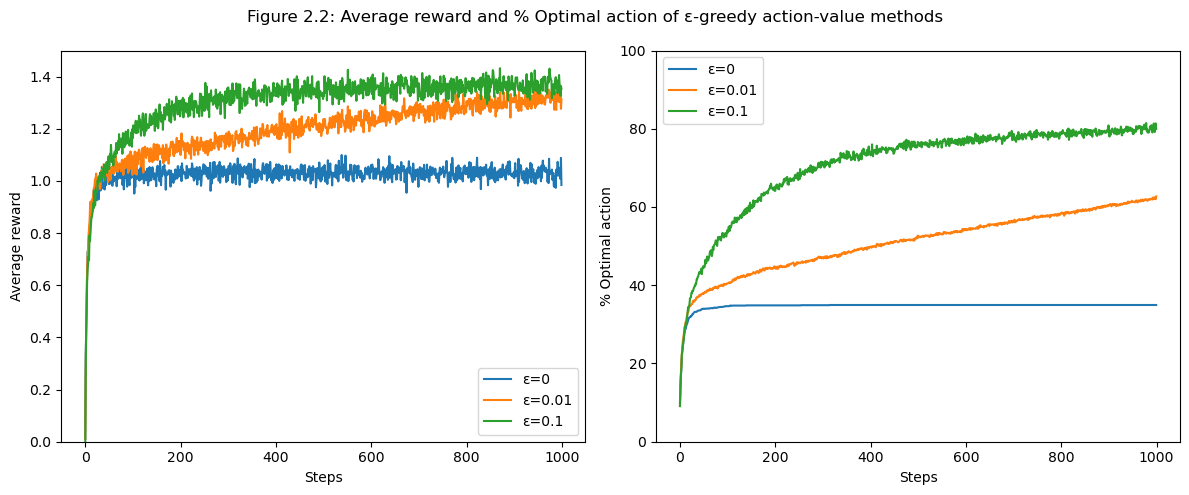

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def run_experiment(epsilon: float, steps: int = 1000, runs: int = 2000) -> tuple[np.ndarray, np.ndarray]:
    rewards = np.zeros(steps)
    optimal_action_counts = np.zeros(steps)

    for _ in range(runs):
        bandit = Bandit()
        optimal_action = np.argmax(bandit.q_true)

        for step in range(steps):
            action = bandit.select_action(epsilon)
            reward = bandit.step(action)
            bandit.update_estimates(action, reward)

            rewards[step] += reward
            if action == optimal_action:
                optimal_action_counts[step] += 1

    rewards /= runs
    optimal_action_counts /= runs

    return rewards, optimal_action_counts

# 매개변수
steps = 1000
runs = 2000
epsilons = [0, 0.01, 0.1]

# 실험 수행
results = {}
for epsilon in epsilons:
    rewards, optimal_action_counts = run_experiment(epsilon)
    results[epsilon] = (rewards, optimal_action_counts)

# 시각화
plt.figure(figsize=(12, 5))
plt.suptitle(r"Figure 2.2: Average reward and % Optimal action of $\varepsilon$-greedy action-value methods")

# 평균 보상 그래프
plt.subplot(1, 2, 1)
for epsilon in epsilons:
    plt.plot(results[epsilon][0], label=rf"$\varepsilon$={epsilon}")
plt.xlabel("Steps")
plt.ylabel("Average reward")
plt.ylim(0, 1.5)
plt.tight_layout()
plt.legend()

# 최적 행동 비율 그래프
plt.subplot(1, 2, 2)
for epsilon in epsilons:
    plt.plot(results[epsilon][1] * 100, label=rf"$\varepsilon$={epsilon}")
plt.xlabel("Steps")
plt.ylabel("% Optimal action")
plt.legend()
plt.ylim(0, 100)
plt.tight_layout()
plt.show()


### Exercise 2.3: 장기적으로 최적인 ε

$\varepsilon = 0.01$인 방법이 탐험과 활용 사이의 균형을 가장 잘 잡아 주며, 충분히 긴 시점에 걸쳐 더 높은 누적 보상을 얻고 최적 행동을 더 자주 선택하게 된다.

## 2.4 점진적 구현

표본 평균을 식 그대로 계산하면 모든 과거 보상을 저장해야 하므로 비효율적이다. 그러나 다음과 같은 **점진적 갱신(incremental update)** 형태로 다시 쓰면, 추정값 하나와 카운터 하나만으로 표본 평균을 유지할 수 있다.

$$Q_{n+1} = Q_n + \frac{1}{n}\big[R_n - Q_n\big]$$

이 식은 강화학습 전반에서 반복적으로 등장하는 **일반적 갱신 형식**의 한 예이다.

$$\text{NewEstimate} \leftarrow \text{OldEstimate} + \text{StepSize}\,\big[\text{Target} - \text{OldEstimate}\big]$$

여기서 대괄호 안의 양 $[\text{Target} - \text{OldEstimate}]$은 추정값의 **오차(error)**이며, 단계 크기(step size)는 그 오차를 얼마나 반영할지를 정한다. 표본 평균에서는 단계 크기가 $1/n$으로 점차 작아지지만, 일정한 단계 크기를 사용하는 변형도 매우 유용하다.

### Exercise 2.4: 비상수 단계 크기 일반화

#### 비상수 단계 크기에 대한 일반화

다음 갱신 규칙에서 출발한다.
$$Q_{n+1} = Q_n + \alpha_n (R_n - Q_n)$$

이를 재귀적으로 풀어, $Q_{n+1}$을 이전의 모든 보상과 단계 크기 매개변수에 대한 식으로 표현하고자 한다.

#### 유도 과정

1. **초기값:**
   $$Q_1$$

2. **첫 번째 갱신:**
   $$Q_2 = Q_1 + \alpha_1 (R_1 - Q_1)$$

3. **두 번째 갱신:**
   $$Q_3 = Q_2 + \alpha_2 (R_2 - Q_2)$$

   $Q_2$를 대입하여 정리하면 다음과 같다.
   $$\begin{aligned}
   Q_3 =& Q_1 + \alpha_1 (R_1 - Q_1) + \alpha_2 (R_2 - (Q_1 + \alpha_1 (R_1 - Q_1))) \\
       =& Q_1 + \alpha_1 (R_1 - Q_1) + \alpha_2 (R_2 - Q_1 - \alpha_1 R_1 + \alpha_1 Q_1) \\
       =& Q_1 (1 - \alpha_1)(1 - \alpha_2) + \alpha_1 R_1 (1 - \alpha_2) + \alpha_2 R_2
   \end{aligned}$$

4. **일반항:**

   같은 방식으로 일반화하면, $Q_{n+1}$을 모든 이전 보상에 대한 식으로 다음과 같이 쓸 수 있다.
   $$Q_{n+1} = Q_1 \prod_{i=1}^n (1 - \alpha_i) + \sum_{k=1}^n \left[ \alpha_k R_k \prod_{j=k+1}^n (1 - \alpha_j) \right]$$

   각 보상 $R_k$에는 단계 크기 $\alpha_k$와, 그 이후 시점들의 $(1 - \alpha_j)$ 곱이 가중치로 작용하고 있음을 알 수 있다.

#### 각 보상에 대한 가중치

따라서 $Q_{n+1}$에서 보상 $R_k$가 차지하는 가중치는 다음과 같다.
$$R_k\text{의 가중치} = \alpha_k \prod_{j=k+1}^n (1 - \alpha_j)$$

오래된 보상일수록 이후 시점의 $(1-\alpha_j)$ 항이 더 많이 곱해지므로, 현재 추정값에 미치는 영향이 점점 줄어든다.

#### 결론

단계 크기 매개변수 $\alpha_n$의 수열에 대한 식 (2.6)의 일반화 형태에서, 각 이전 보상에 대한 가중치는
$$\alpha_k \prod_{j=k+1}^n (1 - \alpha_j)$$
이다. 이는 단계 크기가 일정하지 않을 때 각 보상이 현재 추정값 $Q_n$에 어떻게 기여하는지를 명확히 드러낸다.

## 2.5 비정적 문제의 추적

행동의 참 가치가 시간에 따라 변하는 **비정적(nonstationary) 환경**에서는, 과거의 모든 보상을 동등하게 평균 내는 표본 평균이 부적절하다. 최근 보상에 더 큰 가중치를 주기 위해 일정한 단계 크기 $\alpha \in (0, 1]$을 쓰는 것이 자연스러운 대안이다.

$$Q_{n+1} = Q_n + \alpha\big[R_n - Q_n\big]$$

이 갱신을 풀어 쓰면 다음과 같다.

$$Q_{n+1} = (1-\alpha)^n Q_1 + \sum_{i=1}^{n} \alpha (1-\alpha)^{n-i} R_i$$

즉 보상 $R_i$의 가중치는 $\alpha (1-\alpha)^{n-i}$로, 시간이 지날수록 **지수적으로 감소**한다. 이러한 갱신을 **지수 감쇠 가중 평균(exponential recency-weighted average)**이라 부른다. 단계 크기를 일정하게 두면 추정값이 한 점으로 수렴하지는 않지만, 그 대신 변화하는 참 가치를 끊임없이 따라갈 수 있다. 강화학습 문제는 대체로 비정적이므로, 실제로는 일정 단계 크기 방식을 더 자주 쓴다.

### Exercise 2.5: 비정적 환경 실험 (프로그래밍)

비정적(nonstationary) 문제에서 표본 평균 방식이 겪는 어려움을 보이기 위한 실험을 설계한다. 10개의 팔 밴딧(10-armed bandit) 문제 위에서 다음 두 방법을 비교한다.

1. 표본 평균을 이용하는 행동 가치 방법
2. 일정한 단계 크기 $\alpha = 0.1$을 사용하는 행동 가치 방법

#### 실험 설정

1. **10개의 팔 테스트베드:**
   - 각 행동 $a$의 초기 참값은 $q_*(a) = 0$으로 둔다.
   - 매 단계마다 모든 $q_*(a)$에 평균 0, 표준편차 0.01인 정규분포 증분을 더해 무작위 보행(random walk)을 시킨다.

2. **두 가지 방법:**
   - **표본 평균 방법:** 지금까지 관측한 모든 보상의 평균으로 행동 가치 추정값을 갱신한다.
   - **일정 단계 크기 방법:** 일정한 단계 크기 $\alpha = 0.1$을 사용하여 갱신한다.

3. **매개변수:**
   - $\varepsilon = 0.1$의 $\varepsilon$-greedy 행동 선택을 사용한다.
   - 한 번의 실행은 10,000 단계로 구성된다.
   - 통계적 신뢰성을 위해 여러 번 실행하며(예: 2,000회), 그 평균을 본다.

#### 구현

다음은 NumPy와 Matplotlib을 사용한 파이썬 구현이다.

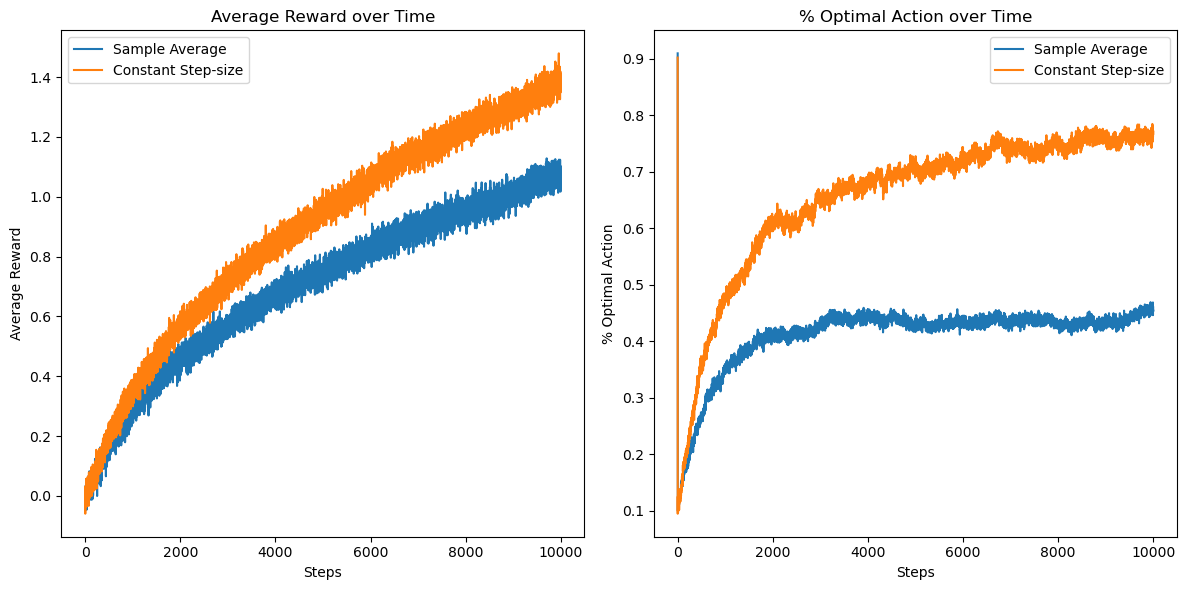

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 매개변수 설정
n_arms = 10
n_steps = 10_000
n_runs = 2_000
epsilon = 0.1
alpha = 0.1
random_walk_std = 0.01

def run_experiment(sample_average: bool = False) -> tuple[np.ndarray, np.ndarray]:
    rewards = np.zeros(n_steps)
    optimal_action_counts = np.zeros(n_steps)

    for _ in range(n_runs):
        q_true = np.zeros(n_arms)        # 행동의 참 가치
        q_estimates = np.zeros(n_arms)   # 행동 가치 추정값
        action_counts = np.zeros(n_arms) # 행동별 선택 횟수

        for step in range(n_steps):
            if np.random.rand() < epsilon:
                action = np.random.choice(n_arms)  # 탐험
            else:
                action = np.argmax(q_estimates)    # 활용

            reward = np.random.normal(q_true[action], 1)  # 정규분포에서 보상 샘플링
            action_counts[action] += 1

            if sample_average:
                q_estimates[action] += (reward - q_estimates[action]) / action_counts[action]
            else:
                q_estimates[action] += alpha * (reward - q_estimates[action])

            rewards[step] += reward
            optimal_action_counts[step] += (action == np.argmax(q_true))

            # 참 가치에 대한 무작위 보행
            q_true += np.random.normal(0, random_walk_std, n_arms)

    rewards /= n_runs
    optimal_action_counts /= n_runs

    return rewards, optimal_action_counts

# 두 방법으로 실험 수행
rewards_sample_average, optimal_action_counts_sample_average = run_experiment(sample_average=True)
rewards_constant_step, optimal_action_counts_constant_step = run_experiment(sample_average=False)

# 결과 시각화
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(rewards_sample_average, label='Sample Average')
plt.plot(rewards_constant_step, label='Constant Step-size')
plt.xlabel('Steps')
plt.ylabel('Average Reward')
plt.legend()
plt.title('Average Reward over Time')

plt.subplot(1, 2, 2)
plt.plot(optimal_action_counts_sample_average, label='Sample Average')
plt.plot(optimal_action_counts_constant_step, label='Constant Step-size')
plt.xlabel('Steps')
plt.ylabel('% Optimal Action')
plt.legend()
plt.title('% Optimal Action over Time')

plt.tight_layout()
plt.show()

#### 설명

1. **초기화:** 팔의 수(`n_arms`), 단계 수(`n_steps`), 실행 횟수(`n_runs`)를 설정하고, `epsilon`과 `alpha`를 정의한다.

2. **`run_experiment` 함수:**
   - 각 단계에 대한 보상과 최적 행동 선택 횟수를 0으로 초기화한다.
   - 결과의 분산을 줄이기 위해 여러 번의 실행을 수행하고 평균을 낸다.
   - 매 단계마다 $\varepsilon$-greedy 정책으로 행동을 선택한다.
   - 표본 평균이나 일정 단계 크기 방식 중 하나로 행동 가치 추정값을 갱신한다.
   - 매 단계마다 참 행동 가치에 무작위 보행을 적용한다.

3. **결과 시각화:**
   - 시간에 따른 평균 보상을 그린다.
   - 시간에 따른 최적 행동 선택 비율을 그린다.

#### 결과 해석

- **평균 보상 그래프:** 일정 단계 크기 방법이 비정적 환경에 더 빠르게 적응하여, 장기적으로 더 높은 보상을 유지한다.
- **최적 행동 비율 그래프:** 일정 단계 크기 방법이 더 자주 최적 행동을 선택한다. 표본 평균 방법은 모든 과거 보상에 동일한 가중치를 부여하므로, 무작위 보행으로 변하는 최적 행동을 따라잡지 못한다.

이 실험은 비정적 환경에서 표본 평균 방법이 갖는 한계를 분명히 드러내며, 일정 단계 크기 매개변수가 환경 변화에 더 잘 적응한다는 점을 잘 보여 준다.

### Exercise 2.7: 편향 없는 일정 단계 크기 트릭

$Q_n$이 초기값 편향 없이 지수적으로 최근 보상에 더 큰 가중치를 두는 평균(exponential recency-weighted average)임을 보이고자 한다.

#### 분석

1. **$\bar{o}_n$의 재귀적 정의:**

   주어진 재귀식
   $$\bar{o}_n = \bar{o}_{n-1} + \alpha (1 - \bar{o}_{n-1})$$
   은 다음과 같이 다시 쓸 수 있다.
   $$\bar{o}_n = (1 - \alpha) \bar{o}_{n-1} + \alpha$$

2. **초기값:**
   $$\bar{o}_0 = 0$$

3. **재귀식의 해:**

   $\bar{o}_n$의 닫힌 형태 해를 구하기 위해 식을 반복 전개하면 다음과 같다.
   $$\begin{aligned}
   \bar{o}_1 &= \alpha, \\
   \bar{o}_2 &= (1 - \alpha) \alpha + \alpha = \alpha (1 + (1 - \alpha)), \\
   \bar{o}_3 &= (1 - \alpha) \alpha (1 + (1 - \alpha)) + \alpha = \alpha (1 + (1 - \alpha) + (1 - \alpha)^2), \\
   &\vdots \\
   \bar{o}_n &= \alpha \sum_{i=0}^{n-1} (1 - \alpha)^i.
   \end{aligned}$$

   등비급수의 합 공식을 사용하면
   $$\sum_{i=0}^{n-1} (1 - \alpha)^i = \frac{1 - (1 - \alpha)^n}{\alpha}$$
   이므로
   $$\bar{o}_n = \alpha \cdot \frac{1 - (1 - \alpha)^n}{\alpha} = 1 - (1 - \alpha)^n.$$

4. **$\beta_n$을 사용한 행동 가치 갱신:**

   단계 크기 $\beta_n$을 사용하는 행동 가치 갱신식은
   $$Q_{n+1} = Q_n + \beta_n (R_n - Q_n)$$
   이며, $\beta_n = \alpha / \bar{o}_n$을 대입하면
   $$Q_{n+1} = Q_n + \frac{\alpha}{\bar{o}_n} (R_n - Q_n)$$
   가 된다.

5. **최근 가중 평균(recency-weighted average):**

   $\bar{o}_n = 1 - (1 - \alpha)^n$이므로
   $$\beta_n = \frac{\alpha}{1 - (1 - \alpha)^n}$$
   이 된다. $n$이 충분히 커지면 $\bar{o}_n$이 1에 가까워지고, 따라서 $\beta_n$은 일정한 $\alpha$로 수렴한다. 즉 단계 크기 $\beta_n$은 학습 초기에는 큰 값을 가져 초기 추정값의 편향을 제거하고, 시간이 지나면서 자연스럽게 일정 단계 크기 방식으로 수렴한다.

   갱신식을 정리하면
   $$\begin{aligned}
   Q_{n+1} =& Q_n + \beta_n (R_n - Q_n) \\
           =& (1 - \beta_n) Q_n + \beta_n R_n
   \end{aligned}$$
   가 되며, 이는 $Q_{n+1}$이 최근 보상에 더 큰 가중치를 부여하고 과거 보상의 영향력이 지수적으로 감소하는 형태임을 보여 준다. 그리고 $\beta_n$의 정의 덕분에 초기값 편향이 발생하지 않는다.

#### 결론

단계 크기 트릭
$$\beta_n \doteq \frac{\alpha}{1 - (1 - \alpha)^n}$$
을 사용하면, $Q_n$은 초기값 편향이 없는 지수 감쇠 가중 평균이 된다. 이는 비정적 환경에서 일정 단계 크기가 갖는 적응성을 그대로 유지하면서도, 초기 추정에서 발생하는 편향을 제거한다.

## 2.6 낙관적 초기값

지금까지의 모든 방법은 초기 추정값 $Q_1(a)$에 어느 정도 의존한다. 통계학적 관점에서는 이를 **편향**으로 보아 부정적으로 평가하지만, 실용적 측면에서는 오히려 사전 지식을 활용하는 유용한 수단이 된다.

대표적 예가 **낙관적 초기값(optimistic initial values)**이다. 모든 행동의 초기 추정값을 참 가치보다 충분히 크게(예컨대 $Q_1(a) = +5$) 설정하면, 어떤 행동을 선택해도 받은 보상이 추정값보다 작으므로, 학습자는 추정값을 낮추게 된다. 그 결과 한동안 모든 행동을 두루 시도하게 되므로, 별도의 탐험 메커니즘 없이도 초기 탐험이 저절로 이루어진다.

이 기법은 정적(stationary) 환경에서 매우 효과적이지만, 어디까지나 탐험을 일시적으로만 유도한다는 한계가 있다. 추정값이 참 가치에 가까워지고 나면 더 이상 탐험을 자극하지 못하므로, 시간이 지나며 행동의 가치가 변하는 비정적 문제에서는 본질적 해결책이 되지 못한다.

### Figure 2.3: 낙관적 초기값의 효과

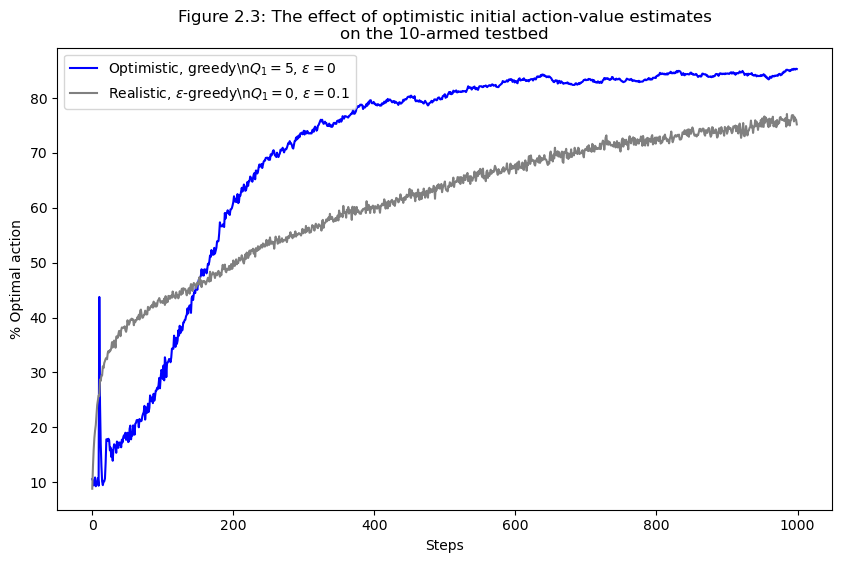

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def run_experiment(epsilon: float, q1: float, steps: int = 1000, runs: int = 2000, alpha: float = 0.1) -> np.ndarray:
    optimal_action_counts = np.zeros(steps)

    for _ in range(runs):
        bandit = Bandit(q1=q1)
        optimal_action = np.argmax(bandit.q_true)

        for step in range(steps):
            action = bandit.select_action(epsilon)
            reward = bandit.step(action)
            bandit.update_estimates(action, reward, alpha)

            if action == optimal_action:
                optimal_action_counts[step] += 1

    optimal_action_counts /= runs

    return optimal_action_counts

# 매개변수
steps = 1000
runs = 2000
alpha = 0.1

# 실험 수행: 낙관적 초기값 vs. 현실적 초기값
optimal_action_counts_optimistic = run_experiment(0, 5, steps, runs, alpha)
optimal_action_counts_realistic = run_experiment(0.1, 0, steps, runs, alpha)


# 시각화
plt.figure(figsize=(10, 6))

# 최적 행동 비율 그래프
plt.plot(optimal_action_counts_optimistic * 100, label=r"Optimistic, greedy\n$Q_1=5$, $\varepsilon=0$", color="blue")
plt.plot(optimal_action_counts_realistic * 100, label=r"Realistic, $\varepsilon$-greedy\n$Q_1=0$, $\varepsilon=0.1$", color="gray")

plt.xlabel("Steps")
plt.ylabel("% Optimal action")
plt.legend()
plt.title("Figure 2.3: The effect of optimistic initial action-value estimates\non the 10-armed testbed")
plt.show()


### Exercise 2.6: 알 수 없는 스파이크

#### 설명

낙관적 초기값(optimistic initial values) 방법의 학습 곡선 초반에 나타나는 기복과 스파이크는 다음과 같은 요인들로 설명할 수 있다.

1. **낙관적 초기값:** 이 방법에서는 행동 가치 추정값 $Q(a)$를 참 가치보다 크게 설정한다. 그 결과 에이전트는 초기에 모든 행동이 매우 좋다고 믿게 되어, 다양한 행동을 적극적으로 시도하면서 탐험을 유도한다.

2. **초기의 강한 탐험:** 추정값이 매우 높게 시작하므로, 에이전트는 곧 실제 보상이 추정값보다 낮다는 사실을 알게 된다. 그 결과 추정값을 빠르게 아래쪽으로 조정하는 일련의 갱신이 일어난다.

3. **초기의 급격한 조정:** 낙관적 추정값이 실제 보상 수준으로 내려앉는 초기 과정에서 $Q$ 값이 크게 흔들리고, 그 여파가 평균 보상과 최적 행동 비율의 기복으로 나타난다.

4. **최적 행동의 빠른 발견:** 낙관적 초기값은 에이전트가 모든 행동을 이른 시점에 시도하게 만든다. 최적 행동을 발견해 활용하기 시작하는 순간 성능이 급격히 오르면서, 학습 곡선 초반에 급변이 나타난다.

5. **무작위 보행의 영향:** 비정적 문제에서는 참 가치가 시간에 따라 변한다. 학습 초반에는 무작위 변동에 의해 일시적으로 가장 좋아 보이는 행동을 에이전트가 우연히 활용할 수 있고, 이때 성능 지표에 일시적인 스파이크가 나타날 수 있다.

6. **높은 분산:** 낙관적 초기값 방법은 본질적으로 강한 탐험을 유도하므로, 학습 초반에 자연스럽게 분산이 커진다. 이러한 큰 분산이 학습 곡선의 기복과 급변으로 드러난다.

#### 요약

낙관적 초기값 방법의 곡선 앞부분에서 관찰되는 기복과 스파이크는 다음 세 가지 요인이 결합한 결과이다.

- 과대평가된 추정값을 빠르게 보정하는 과정에서 일어나는 큰 폭의 갱신.
- 초반의 강한 탐험으로 인한 성능의 급격한 흔들림.
- 비정적 환경에서 참 가치가 변함에 따라 일시적으로 우월해 보이는 행동을 활용하면서 발생하는 스파이크.

추정값이 안정화되어 가면서 이러한 초기 불안정성은 점차 사라지고, 장기적으로는 보다 안정적인 성능을 보이게 된다.

## 2.7 신뢰 상한 행동 선택

$\varepsilon$-greedy 방법은 탐험 시 행동을 무작위로 고르기 때문에, 차선일 가능성이 높은 행동과 탐험 여지가 남은 행동을 똑같이 취급한다. **신뢰 상한(Upper-Confidence-Bound, UCB)** 방법은 이 한계를 보완해, 추정값에 **탐험 유인**을 더한 값이 가장 큰 행동을 고른다.

$$A_t = \arg\max_a \left[ Q_t(a) + c\,\sqrt{\frac{\ln t}{N_t(a)}} \right]$$

여기서 $N_t(a)$는 시점 $t$까지 행동 $a$를 선택한 횟수이고, $c > 0$은 탐험 강도를 조절하는 매개변수이다. 행동 $a$를 선택할수록 $N_t(a)$가 커져 탐험 유인이 줄고, 다른 행동을 선택해 $t$가 늘어날수록 탐험 유인이 다시 커진다. 결국 UCB는 추정 가치가 높거나 탐험이 부족한 행동을 자연스럽게 우선시한다.

10개의 팔 테스트베드에서 UCB는 일반적으로 $\varepsilon$-greedy보다 우수한 성능을 보인다. 다만 비정적 문제나 상태 공간이 큰 강화학습 문제로 확장하기는 까다롭다.

### Figure 2.4: UCB와 ε-greedy 성능 비교

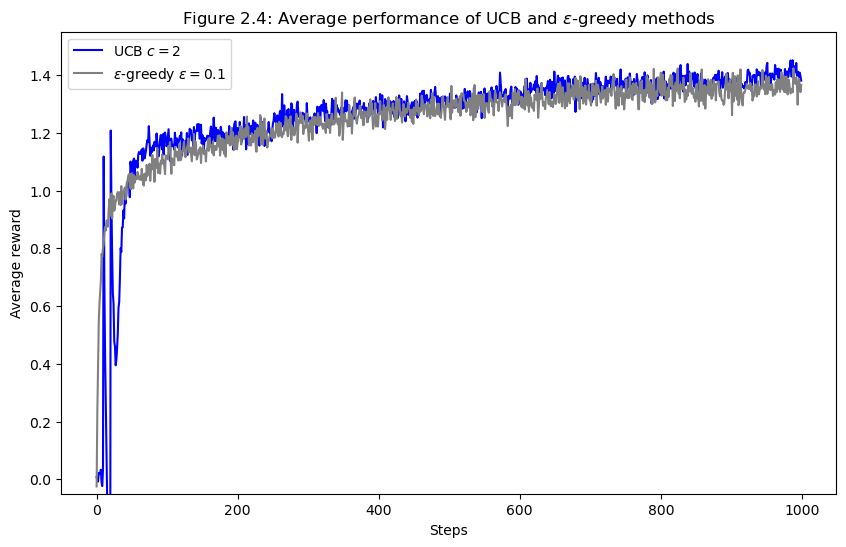

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def ucb_action_selection(bandit: Bandit, c: float) -> int | np.integer:
    ucb_values = bandit.q_estimates + c * np.sqrt(np.log(bandit.time + 1) / (bandit.action_counts + 1e-5))
    return np.argmax(ucb_values)

def run_experiment_ucb(c: float, steps: int = 1000, runs: int = 2000, alpha: float = 0.1) -> np.ndarray:
    rewards = np.zeros(steps)

    for _ in range(runs):
        bandit = Bandit()

        for step in range(steps):
            bandit.time = step
            action = ucb_action_selection(bandit, c)
            reward = bandit.step(action)
            bandit.update_estimates(action, reward, alpha)
            rewards[step] += reward

    rewards /= runs

    return rewards

def run_experiment_epsilon(epsilon: float, steps: int = 1000, runs: int = 2000, alpha: float = 0.1) -> np.ndarray:
    rewards = np.zeros(steps)

    for _ in range(runs):
        bandit = Bandit()

        for step in range(steps):
            action = bandit.select_action(epsilon)
            reward = bandit.step(action)
            bandit.update_estimates(action, reward, alpha)
            rewards[step] += reward

    rewards /= runs

    return rewards

# 매개변수
steps = 1000
runs = 2000
alpha = 0.1

# 실험 수행
rewards_ucb = run_experiment_ucb(c=2, steps=steps, runs=runs, alpha=alpha)
rewards_epsilon = run_experiment_epsilon(epsilon=0.1, steps=steps, runs=runs, alpha=alpha)

# 시각화
plt.figure(figsize=(10, 6))

# 평균 보상 그래프
plt.plot(rewards_ucb, label="UCB $c=2$", color="blue")
plt.plot(rewards_epsilon, label=r"$\varepsilon$-greedy $\varepsilon=0.1$", color="gray")

plt.ylim(-0.05, 1.55)
plt.xlabel("Steps")
plt.ylabel("Average reward")
plt.legend()
plt.title(r"Figure 2.4: Average performance of UCB and $\varepsilon$-greedy methods")
plt.show()


### Exercise 2.8: UCB 스파이크

#### 11번째 단계의 스파이크에 대한 분석

##### 1. 초기 탐험 단계

처음 10단계 동안 UCB 알고리즘은 $\sqrt{\ln t / N_t(a)}$ 항 덕분에 모든 행동을 적어도 한 번씩 시도하게 만든다. 아직 한 번도 시도하지 않은 행동은 이 항이 무한대로 커지므로, 알고리즘이 그 행동을 우선 고른다. 이 단계에서 각 행동의 초기 보상 추정값을 수집한다.

##### 2. 11번째 단계

11번째 단계에 이르면 10개의 행동을 모두 정확히 한 번씩 시도한 상태이다. 이때 모든 행동에 대해 $N_t(a) = 1$이고 $t = 11$이므로, $\sqrt{\ln t / N_t(a)}$ 항이 모든 행동에서 같아진다. 결과적으로 알고리즘은 추정 가치 $Q_t(a)$가 가장 큰 행동을 고른다. 초기 탐험에서 평균보다 눈에 띄게 높은 보상을 보인 행동이 있다면, 알고리즘이 그 행동을 다시 고를 가능성이 매우 높다. 이로 인해 평균 보상에 뚜렷한 스파이크가 나타난다.

##### 3. 이후 단계

11번째 단계 이후에는 UCB 알고리즘이 다시 탐험과 활용 사이의 균형을 잡아 간다. 알고리즘은 $Q_t(a)$가 큰 행동을 더 자주 고르지만, $\sqrt{\ln t / N_t(a)}$ 항 덕분에 덜 시도한 행동도 꾸준히 고른다. 이러한 균형 조정 과정에서 평균 보상은 일시적으로 줄어들 수 있다. 11번째 단계에서 우연히 좋게 보였던 행동이 추가 표본을 통해 사실은 차선임이 드러나는 경우가 그 대표적인 예이다.

#### $c = 1$일 때 스파이크가 덜 두드러지는 이유

탐험 정도를 조절하는 매개변수 $c$가 작을수록, 알고리즘은 추정 가치 $Q_t(a)$에 더 크게 의존한다. $c = 1$일 때 탐험 항 $c\sqrt{\ln t / N_t(a)}$는 더 작아지므로, 탐험과 활용 사이의 전환이 한층 부드러워진다. 그 결과 11번째 단계 부근의 스파이크 또한 완만해진다.

#### 결론

UCB 알고리즘 곡선에서 11번째 단계에 스파이크가 나타나는 이유는 다음과 같이 정리할 수 있다.

- 처음 10단계 동안 알고리즘이 모든 행동을 정확히 한 번씩 선택하도록 보장한다.
- 11번째 단계에서는 탐험 항이 모든 행동에 대해 동일해지면서, 초기 탐험으로 가장 높은 추정값을 얻은 행동이 자연스럽게 선택된다.
- 이후에는 추가 탐험과 추정값 정교화가 이어지면서, 일시적으로 평균 보상이 감소한다.

탐험 매개변수 $c$를 작게 잡으면 탐험의 강도가 줄어 곡선이 부드러워지고, 그 결과 11번째 단계의 스파이크 역시 덜 두드러지게 나타난다.

## 2.8 선호도 밴딧 알고리즘

지금까지의 방법은 모두 행동의 가치를 추정하고 그 추정값을 기반으로 행동을 골랐다. **선호도 밴딧(gradient bandit) 알고리즘**은 접근 방식이 다르다. 각 행동에 **선호도(preference)** $H_t(a)$라는 점수를 부여하고, 선호도가 높을수록 그 행동을 고를 확률이 높아지도록 소프트맥스로 설계한다. 선호도는 보상의 절대적 추정값이 아니라 행동들 사이의 상대적 순위에 해당한다.

$$\Pr\{A_t = a\} \doteq \frac{e^{H_t(a)}}{\sum_{b=1}^{k} e^{H_t(b)}} \doteq \pi_t(a)$$

갱신의 방향은 단순하다. 받은 보상 $R_t$가 지금까지의 평균인 **보상 기준치(baseline)** $\bar{R}_t$보다 높으면 — 기대보다 좋은 결과 — 방금 고른 행동의 선호도를 올리고 나머지 행동의 선호도는 내린다. 반대로 기준치보다 낮으면 방향이 바뀐다.

$$
\begin{aligned}
H_{t+1}(A_t) &\doteq H_t(A_t) + \alpha (R_t - \bar{R}_t)(1 - \pi_t(A_t)) \\
H_{t+1}(a) &\doteq H_t(a) - \alpha (R_t - \bar{R}_t)\,\pi_t(a), \quad a \neq A_t
\end{aligned}
$$

이 갱신 규칙은 기대 보상을 최대화하는 **확률 경사 상승법(stochastic gradient ascent)**과 수학적으로 동일하다. 기준치를 어떻게 잡든 최종 정책은 달라지지 않지만, 분산을 줄여 학습 속도와 안정성을 높이므로 선택에 신경 써야 한다.

### Figure 2.5: 선호도 밴딧의 기준치 유무 비교

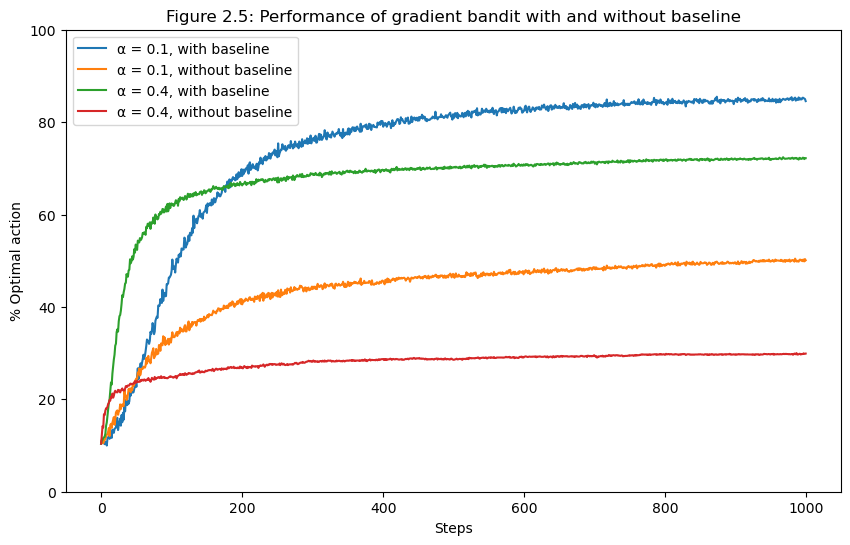

In [ ]:
from concurrent.futures import ProcessPoolExecutor

import numpy as np
import matplotlib.pyplot as plt

def run_experiment(alpha: float, use_baseline: bool, steps: int = 1000, runs: int = 2000) -> np.ndarray:
    optimal_action_counts = np.zeros(steps)

    for _ in range(runs):
        bandit = GradientBandit(alpha=alpha, mu=4, use_baseline=use_baseline)
        optimal_action = np.argmax(bandit.q_true)

        for step in range(steps):
            action = bandit.select_action()
            reward = np.random.normal(bandit.q_true[action], 1)
            bandit.update_preferences(action, reward)

            if action == optimal_action:
                optimal_action_counts[step] += 1

    optimal_action_counts /= runs

    return optimal_action_counts

# 매개변수
steps = 1000
runs = 2000
alphas = [0.1, 0.4]

# 병렬 실행을 위한 인자 준비
args_with_baseline = [(alpha, True, steps, runs) for alpha in alphas]
args_without_baseline = [(alpha, False, steps, runs) for alpha in alphas]

# 실험 수행
results_with_baseline = {}
results_without_baseline = {}

def run_experiment_wrapper(args: tuple[float, bool, int, int]) -> np.ndarray:
    return run_experiment(*args)

with ProcessPoolExecutor() as executor:
    # 베이스라인 사용
    futures_with_baseline = executor.map(run_experiment_wrapper, args_with_baseline)
    for alpha, result in zip(alphas, futures_with_baseline):
        results_with_baseline[alpha] = result

    # 베이스라인 미사용
    futures_without_baseline = executor.map(run_experiment_wrapper, args_without_baseline)
    for alpha, result in zip(alphas, futures_without_baseline):
        results_without_baseline[alpha] = result

# 시각화
plt.figure(figsize=(10, 6))

# 최적 행동 비율 그래프
for alpha in alphas:
    plt.plot(results_with_baseline[alpha] * 100, label=rf"$\alpha$ = {alpha}, with baseline")
    plt.plot(results_without_baseline[alpha] * 100, label=rf"$\alpha$ = {alpha}, without baseline")

plt.ylim(0, 100)
plt.xlabel("Steps")
plt.ylabel("% Optimal action")
plt.legend()
plt.title("Figure 2.5: Performance of gradient bandit with and without baseline")
plt.show()


### Exercise 2.9: 소프트맥스와 로지스틱 함수

두 개의 행동 $a_1$, $a_2$와 그 행동 가치 $q_1$, $q_2$에 대해 소프트맥스(softmax) 함수를 다음과 같이 정의한다.

$$P(a_1) = \frac{e^{q_1}}{e^{q_1} + e^{q_2}}, \qquad P(a_2) = \frac{e^{q_2}}{e^{q_1} + e^{q_2}}$$

$P(a_1)$의 분모에서 $e^{q_1}$을 뽑아내어 정리하면

$$P(a_1) = \frac{e^{q_1}}{e^{q_1}(1 + e^{q_2 - q_1})} = \frac{1}{1 + e^{q_2 - q_1}}$$

가 된다. 한편 로지스틱(시그모이드) 함수는

$$\sigma(x) = \frac{1}{1 + e^{-x}}$$

로 정의되므로, $x = q_1 - q_2$로 두면

$$\sigma(q_1 - q_2) = \frac{1}{1 + e^{-(q_1 - q_2)}} = \frac{1}{1 + e^{q_2 - q_1}}$$

가 된다. 따라서

$$P(a_1) = \sigma(q_1 - q_2)$$

임을 알 수 있다. 같은 방식으로 $P(a_2)$를 정리하면

$$P(a_2) = \frac{e^{q_2}}{e^{q_2}(1 + e^{q_1 - q_2})} = \frac{1}{1 + e^{q_1 - q_2}} = \sigma(q_2 - q_1)$$

가 된다. 시그모이드 함수는 $\sigma(x) + \sigma(-x) = 1$을 만족하므로

$$\sigma(q_1 - q_2) + \sigma(q_2 - q_1) = 1$$

이 자연스럽게 성립한다. 결과적으로 행동이 두 개일 때 소프트맥스 분포는 통계학과 인공신경망에서 널리 쓰이는 로지스틱(시그모이드) 함수와 정확히 같은 형태로 환원할 수 있다.

## 2.9 연관 탐색(맥락 밴딧)

지금까지 다룬 밴딧 문제는 모두 상황이 단 하나로 고정되어 있다고 가정했다. 그러나 실제 문제에서는 **상황(situation)**에 따라 최선의 행동이 달라지는 경우가 많다. 예를 들어 표시된 색깔에 따라 최적의 팔이 바뀌는 슬롯머신을 떠올릴 수 있다.

이러한 과제를 **연관 탐색(associative search)** 또는 **맥락 밴딧(contextual bandit)**이라 부른다. 단순한 탐색뿐 아니라 상황과 최적 행동을 연결하는 학습도 함께 필요하다.

맥락 밴딧은 한 행동이 즉각 보상에만 영향을 미치고 다음 상황에는 영향을 주지 않는다는 점에서 단순한 밴딧 문제와 같다. 그러나 상황이 여러 개라는 점에서 일반 강화학습 문제와 닿아 있어, 두 문제를 잇는 **중간 단계** 격이다.

### Exercise 2.10: 맥락에 따른 최적의 기대 보상

#### 문제 정리

두 개의 팔을 가진 밴딧 과제이며, 참 행동의 가치는 다음 두 경우 중 하나에 해당한다.

- **경우 A:** 행동 1의 가치는 10, 행동 2의 가치는 20이다.
- **경우 B:** 행동 1의 가치는 90, 행동 2의 가치는 80이다.

각 경우는 확률 0.5로 발생한다. 매 시점 자신이 어느 경우에 놓여 있는지 알 수 없는 상황과, 어느 경우에 놓여 있는지를 알 수 있는 상황을 각각 구분하여 분석한다.

#### Part 1. 경우를 알 수 없을 때의 최적 기대 보상

매 시점 자신이 어느 경우에 있는지 알 수 없을 때는, 두 경우에 걸친 평균 보상으로 각 행동을 평가해야 한다.

**행동 1의 기대 보상:**
$$E[R_1] = 0.5 \times 10 + 0.5 \times 90 = 50$$

**행동 2의 기대 보상:**
$$E[R_2] = 0.5 \times 20 + 0.5 \times 80 = 50$$

두 행동의 기대 보상이 모두 50으로 같으므로, 어느 행동을 선택하더라도 기대 보상은 50이 된다.

#### Part 2. 경우를 알 수 있을 때의 최적 기대 보상

이번에는 자신이 경우 A인지 경우 B인지를 알 수 있다고 하자. 이는 일종의 연관 탐색(associative search) 과제가 된다.

**전략:**
- **경우 A:** 행동 2를 선택한다(20 > 10).
- **경우 B:** 행동 1을 선택한다(90 > 80).

**기대 보상 계산:**

- 경우 A에서 행동 2를 선택하면 보상은 20이다.
- 경우 B에서 행동 1을 선택하면 보상은 90이다.

각 경우가 확률 0.5로 발생하므로 기대 보상은 다음과 같다.
$$E[R] = 0.5 \times 20 + 0.5 \times 90 = 55$$

#### 요약

- 자신이 어느 경우에 있는지 알 수 없을 때는 어떤 행동을 선택해도 기대 보상이 50으로 같다.
- 자신이 어느 경우에 있는지 알 수 있을 때는 각 경우마다 더 큰 가치를 가진 행동을 선택함으로써 기대 보상 55를 달성할 수 있다.

따라서 이 과제에서 얻을 수 있는 최대 기대 보상은 **55** 이며, 이는 각 경우에 맞춰 최적 행동을 선택할 때 달성된다.

## 2.10 요약

2장에서 다룬 방법들은 모두 단일 상태 환경에서 **탐험과 활용의 균형**을 각기 다른 방식으로 풀어낸다.

- **$\varepsilon$-greedy 방법**은 $\varepsilon$의 확률로 무작위 행동을 골라 탐험을 유도한다.
- **UCB 방법**은 각 행동의 불확실성을 정량화해, 탐험 여지가 큰 행동을 우선시한다.
- **선호도 밴딧 알고리즘**은 가치를 추정하는 대신, 보상 신호를 따라 행동의 선호도를 직접 학습한다.
- **낙관적 초기값**은 추정값을 일부러 높게 잡아 초기 탐험을 유도한다.

어느 방법이 절대적으로 우월하지는 않다. 매개변수를 적절히 조정하면 각 방법이 비슷한 성능을 내므로, 문제의 성격(정적/비정적, 잡음의 크기, 시간 척도 등)에 맞춰 방법과 매개변수를 골라야 한다.

이론적으로는 베이지안 관점에서 동적 계획법으로 최적 탐험–활용 균형을 직접 계산할 수도 있다. 이는 **기틴스 인덱스(Gittins index)** 같은 우아한 결과로 이어지지만, 계산 비용이 너무 커서 실용적이지 않다. 결국 단순하면서도 충분히 잘 작동하는 $\varepsilon$-greedy, UCB, 선호도 밴딧이 이후 장에서 다룰 강화학습 문제의 출발점이 된다.

### Figure 2.6: 밴딧 알고리즘 매개변수 연구

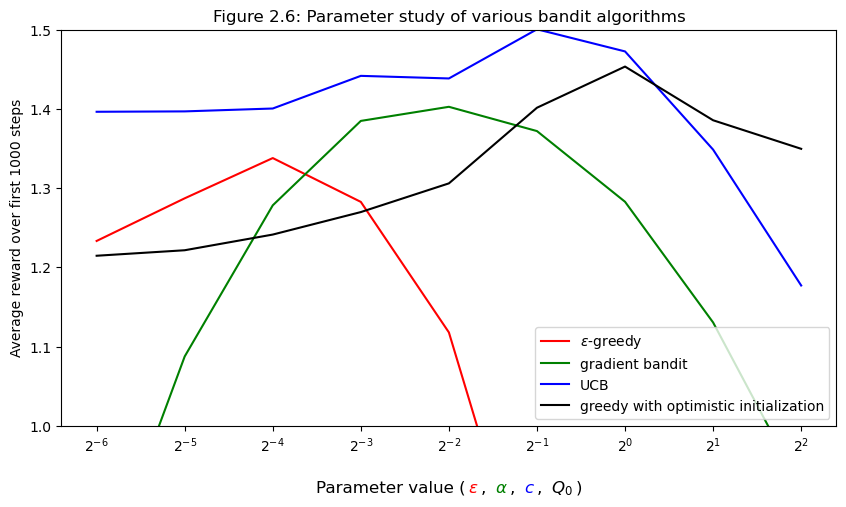

In [ ]:
from concurrent.futures import ProcessPoolExecutor

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.offsetbox import AnchoredOffsetbox, HPacker, TextArea


def ucb_action_selection(bandit: Bandit, c: float) -> int | np.integer:
    ucb_values = bandit.q_estimates + c * np.sqrt(
        np.log(bandit.time + 1) / (bandit.action_counts + 1e-5)
    )
    return np.argmax(ucb_values)


def run_experiment(method: str, param: float, steps: int = 1000, runs: int = 2000) -> float:
    rewards = np.zeros(steps)

    for _ in range(runs):
        if method == "epsilon_greedy":
            bandit = Bandit()
            for step in range(steps):
                action = bandit.select_action(param)
                reward = bandit.step(action)
                bandit.update_estimates(action, reward)
                rewards[step] += reward

        elif method == "ucb":
            bandit = Bandit()
            for step in range(steps):
                bandit.time = step
                action = ucb_action_selection(bandit, param)
                reward = bandit.step(action)
                bandit.update_estimates(action, reward)
                rewards[step] += reward

        elif method == "gradient_bandit":
            bandit = GradientBandit(alpha=param, use_baseline=True)
            for step in range(steps):
                action = bandit.select_action()
                reward = np.random.normal(bandit.q_true[action], 1)
                bandit.update_preferences(action, reward)
                rewards[step] += reward

        elif method == "optimistic_greedy":
            bandit = Bandit(q1=param)
            for step in range(steps):
                action = bandit.select_action(0)
                reward = bandit.step(action)
                bandit.update_estimates(action, reward, alpha=0.1)
                rewards[step] += reward

    rewards /= runs
    return np.mean(rewards)


# 매개변수
steps = 1000
runs = 2000

epsilon_values = [1 / 64, 1 / 32, 1 / 16, 1 / 8, 1 / 4, 1 / 2, 1, 2, 4]
alpha_values = epsilon_values
c_values = epsilon_values
q0_values = epsilon_values


# 튜플 인자 처리를 위한 래퍼 함수
def run_experiment_wrapper(args: tuple[str, float, int, int]) -> float:
    return run_experiment(*args)


# 병렬 실행을 위한 매개변수 준비
experiment_params = []
experiment_params.extend(
    [("epsilon_greedy", eps, steps, runs) for eps in epsilon_values]
)
experiment_params.extend(
    [("gradient_bandit", alpha, steps, runs) for alpha in alpha_values]
)
experiment_params.extend([("ucb", c, steps, runs) for c in c_values])
experiment_params.extend([("optimistic_greedy", q0, steps, runs) for q0 in q0_values])

# 실험을 병렬로 실행
results = []
with ProcessPoolExecutor() as executor:
    results = list(executor.map(run_experiment_wrapper, experiment_params))

# 결과를 방법별로 분리
total_types = 4  # 실험 방법의 수
each_type_count = len(
    epsilon_values
)  # 모든 매개변수 리스트의 길이가 동일하다고 가정

epsilon_rewards = results[:each_type_count]
alpha_rewards = results[each_type_count : 2 * each_type_count]
c_rewards = results[2 * each_type_count : 3 * each_type_count]
q0_rewards = results[3 * each_type_count : 4 * each_type_count]

# 시각화
plt.figure(figsize=(10, 6))

plt.plot(epsilon_values, epsilon_rewards, label=r"$\varepsilon$-greedy", color="red")
plt.plot(alpha_values, alpha_rewards, label=r"gradient bandit", color="green")
plt.plot(c_values, c_rewards, label=r"UCB", color="blue")
plt.plot(
    q0_values, q0_rewards, label=r"greedy with optimistic initialization", color="black"
)

plt.ylim(1, 1.5)
plt.xticks(epsilon_values, ["1/64", "1/32", "1/16", "1/8", "1/4", "1/2", "1", "2", "4"])
plt.xscale("log", base=2)

ax = plt.gca()
label_parts = [
    ("Parameter value (", "black"),
    (r"$\varepsilon$", "red"),
    (", ", "black"),
    (r"$\alpha$", "green"),
    (", ", "black"),
    (r"$c$", "blue"),
    (", ", "black"),
    (r"$Q_0$", "black"),
    (")", "black"),
]
label_boxes = [
    TextArea(text, textprops={"color": color, "fontsize": 12})
    for text, color in label_parts
]
xlabel_box = HPacker(children=label_boxes, align="center", pad=0, sep=2)
anchored_xlabel = AnchoredOffsetbox(
    loc="lower center",
    child=xlabel_box,
    pad=0,
    borderpad=0,
    frameon=False,
    bbox_to_anchor=(0.5, -0.18),
    bbox_transform=ax.transAxes,
)
ax.add_artist(anchored_xlabel)
plt.subplots_adjust(bottom=0.22)
plt.ylabel("Average reward over first 1000 steps")
plt.legend()
plt.title("Figure 2.6: Parameter study of various bandit algorithms")
plt.show()


### Exercise 2.11: ε-greedy 장기 성능 측정 (프로그래밍)

아래 코드는 비정적(nonstationary) 10개의 팔 밴딧 문제에서 일정 단계 크기 $\alpha = 0.1$을 사용하는 $\varepsilon$-greedy 알고리즘의 장기 성능을 측정한다. 보상의 참값이 무작위 보행을 통해 천천히 변하는 환경에서, 마지막 100,000 단계의 평균 보상을 출력하고, 이동 평균 형태로 성능 곡선을 그린다.

마지막 100,000 단계의 평균 보상: 5.746607859059822


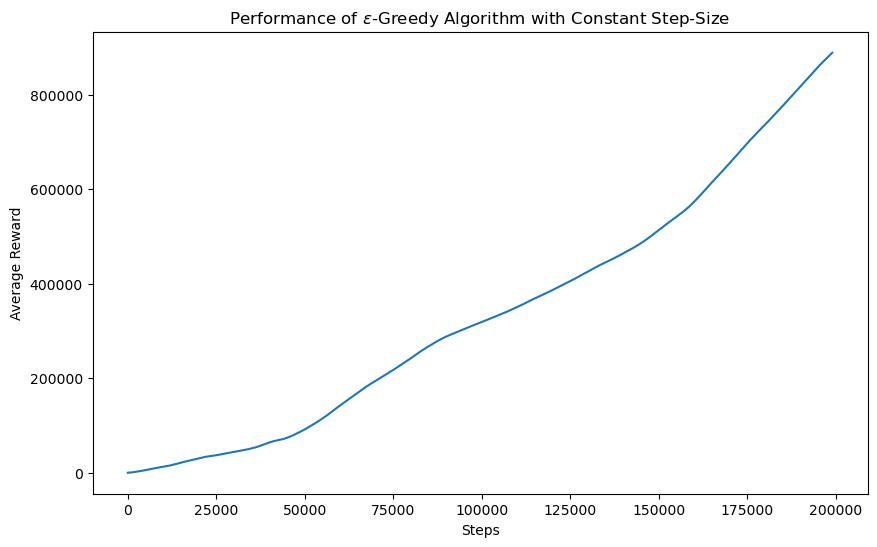

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 매개변수
num_actions = 10
num_steps = 200000
alpha = 0.1
epsilon = 0.1

# 비정적 밴딧 문제 정의
class NonstationaryBandit:
    def __init__(self, num_actions: int) -> None:
        self.num_actions = num_actions
        self.q_true = np.zeros(num_actions)

    def step(self, action: int | np.integer) -> float:
        reward = np.random.randn() + self.q_true[action]
        # 참 가치를 천천히 변화시키는 무작위 보행
        self.q_true += np.random.normal(0, 0.01, self.num_actions)
        return reward

# 일정 단계 크기를 사용하는 엡실론-탐욕적 알고리즘
def epsilon_greedy_bandit(alpha: float, epsilon: float, num_actions: int, num_steps: int) -> np.ndarray:
    bandit = NonstationaryBandit(num_actions)
    q_estimates = np.zeros(num_actions)
    rewards = np.zeros(num_steps)

    for step in range(num_steps):
        if np.random.rand() < epsilon:
            action = np.random.choice(num_actions)
        else:
            action = np.argmax(q_estimates)

        reward = bandit.step(action)
        q_estimates[action] += alpha * (reward - q_estimates[action])
        rewards[step] = reward

    return rewards

# 시뮬레이션 실행
rewards = epsilon_greedy_bandit(alpha, epsilon, num_actions, num_steps)

# 마지막 100,000 단계에 대한 평균 보상
average_reward_last_100k = np.mean(rewards[-100000:])

print(f"마지막 100,000 단계의 평균 보상: {average_reward_last_100k}")

# 결과 시각화
plt.figure(figsize=(10, 6))
plt.plot(np.convolve(rewards, np.ones(1000)/1000, mode='valid'))
plt.xlabel('Steps')
plt.ylabel('Average Reward')
plt.title(r'Performance of $\varepsilon$-Greedy Algorithm with Constant Step-Size')
plt.show()